# MuRIL Training — Multilingual Hate Speech & Misinformation
**Jay Modhiya | Krishna Nandi | SIT Pune — NLPA + MLOps Project**

Runtime: GPU P100 or T4 x2 | Expected time: ~35 min per task

In [6]:
# ── Step 1: Install dependencies ──
!pip install transformers datasets mlflow scikit-learn seaborn -q

In [7]:
# ── Step 2: Clone your GitHub repo ──
# Replace with your actual GitHub repo URL
!git clone https://github.com/Jay-Modhiya/multilingual-hate-misinfo.git
%cd multilingual-hate-misinfo

Cloning into 'multilingual-hate-misinfo'...
remote: Enumerating objects: 18042, done.
remote: Total 18042 (delta 0), reused 0 (delta 0), pack-reused 18042 (from 1)
Receiving objects: 100% (18042/18042), 150.48 MiB | 21.69 MiB/s, done.
Resolving deltas: 100% (1541/1541), done.
Updating files: 100% (17106/17106), done.
/kaggle/working/multilingual-hate-misinfo


In [12]:
import os

# Check what Kaggle input folder actually contains
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/jaymodhiya/hasoc-hindi/hasoc_test.tsv
/kaggle/input/datasets/jaymodhiya/hasoc-hindi/hasoc_train.tsv


In [13]:
# ── Step 3: Upload HASOC data files ──
# Upload hasoc_train.tsv and hasoc_test.tsv via Kaggle sidebar
import os
os.makedirs('data/raw', exist_ok=True)

# After running the check above, use the exact path shown
# It will be something like:
!cp /kaggle/input/datasets/jaymodhiya/hasoc-hindi/hasoc_train.tsv data/raw/hasoc_train.tsv
!cp /kaggle/input/datasets/jaymodhiya/hasoc-hindi/hasoc_test.tsv  data/raw/hasoc_test.tsv

print('Data ready ✓')

Data ready ✓


In [14]:
# ── Step 4: Verify GPU ──
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('Memory:', round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), 'GB')

CUDA available: True
GPU: Tesla P100-PCIE-16GB
Memory: 17.1 GB


In [10]:
# ── Step 5: Verify all datasets load ──
from src.data.loader import load_config, load_all_datasets
cfg = load_config('configs/config.yaml')
datasets = load_all_datasets(cfg)
for name, splits in datasets.items():
    print(f"{name}: train={len(splits['train'])}  val={len(splits['val'])}  test={len(splits['test'])}")

INFO | src.data.loader | Loading Davidson dataset …
INFO | datasets | TensorFlow version 2.19.0 available.
INFO | datasets | JAX version 0.7.2 available.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'tweet_eval' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR | datasets.load | `trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'tweet_eval' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/tweet_eval/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/cardiffnlp/twe

README.md: 0.00B [00:00, ?B/s]

INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/tweet_eval/resolve/b3a375baf0f409c77e6bc7aa35102b7b3534f8be/tweet_eval.py "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/cardiffnlp/tweet_eval/resolve/b3a375baf0f409c77e6bc7aa35102b7b3534f8be/tweet_eval.py "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/tweet_eval/tweet_eval.py "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: GET https://huggingface.co/api/datasets/tweet_eval/revision/b3a375baf0f409c77e6bc7aa35102b7b3534f8be "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: GET https://huggingface.co/api/datasets/cardiffnlp/tweet_eval/revision/b3a375baf0f409c77e6bc7aa35102b7b3534f8be "HTTP/1.1 200 OK"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/tweet_eval/resolve/b3a375baf0f409c77e6bc7aa35102b7b3534f8be/.huggingface.yaml "HTTP/1.1 307 Temporary Redirect

hate/train-00000-of-00001.parquet:   0%|          | 0.00/816k [00:00<?, ?B/s]

INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/tweet_eval/resolve/b3a375baf0f409c77e6bc7aa35102b7b3534f8be/hate/test-00000-of-00001.parquet "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/cardiffnlp/tweet_eval/resolve/b3a375baf0f409c77e6bc7aa35102b7b3534f8be/hate/test-00000-of-00001.parquet "HTTP/1.1 302 Found"


...

Generating train split:   0%|          | 0/24353 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8117 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8117 [00:00<?, ? examples/s]

INFO | src.data.loader | FakeNewsNet loaded from HuggingFace  |  rows: 40587
INFO | src.data.loader | Split → train:28395  val:4057  test:8113


davidson: train=9079  val=1297  test=2594
hasoc: train=4187  val=599  test=1197
fakenewsnet: train=28395  val=4057  test=8113


In [16]:
!pip install torch==2.2.2+cu118 --index-url https://download.pytorch.org/whl/cu118 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.1/819.1 MB 1.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 5.0 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 33.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 96.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 2.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 6.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 32.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 2.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 8.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 MB 13.4 MB/s eta 0:00:0000:0100:01
     ━━━━

In [17]:
# Restart kernel:

import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

In [1]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

x = torch.tensor([1.0]).cuda()
print("CUDA test:", x, "✓")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-packag

PyTorch: 2.2.2+cu118
CUDA: True
GPU: Tesla P100-PCIE-16GB
CUDA test: tensor([1.], device='cuda:0') ✓


In [2]:
import os, sys
os.chdir('/kaggle/working/multilingual-hate-misinfo')
sys.path.insert(0, '/kaggle/working/multilingual-hate-misinfo')

content = open('src/training/trainer.py').read()
content = content.replace(
    'from torch.cuda.amp import GradScaler, autocast',
    'from torch.amp import GradScaler, autocast'
)
content = content.replace(
    'GradScaler() if use_fp16 else None',
    'GradScaler("cuda") if use_fp16 else None'
)
content = content.replace(
    'with autocast():',
    'with autocast("cuda"):'
)
open('src/training/trainer.py', 'w').write(content)
print("trainer.py fixed ✓")

trainer.py fixed ✓


In [3]:
from src.data.loader import load_config
cfg = load_config('configs/config.yaml')
print("Config loaded ✓")

Config loaded ✓


In [5]:
import os
os.chdir('/kaggle/working/multilingual-hate-misinfo')

content = open('src/training/trainer.py').read()

# Remove the problematic import
content = content.replace('import mlflow.pytorch\n', '')

open('src/training/trainer.py', 'w').write(content)
print("Fixed ✓")

# Verify it's gone
lines = [l for l in open('src/training/trainer.py').readlines() if 'mlflow' in l]
print("Remaining mlflow imports:")
for l in lines:
    print(" ", l.strip())

Fixed ✓
Remaining mlflow imports:
  import mlflow
  mlflow.set_tracking_uri(cfg["mlflow"]["tracking_uri"])
  mlflow.set_experiment(f"{cfg['mlflow']['experiment_name']}-{task}")
  with mlflow.start_run(run_name=f"muril-{task}-{time.strftime('%Y%m%d-%H%M')}"):
  mlflow.log_params({
  mlflow.set_tags(cfg["mlflow"]["tags"])
  mlflow.log_metrics({
  mlflow.log_metrics({
  mlflow.log_artifact(cm_path)
  mlflow.log_artifact(best_model_path)


In [7]:
import os
os.chdir('/kaggle/working/multilingual-hate-misinfo')

content = open('src/training/trainer.py').read()

# Fix GradScaler import location
content = content.replace(
    'from torch.amp import GradScaler, autocast',
    'from torch.cuda.amp import GradScaler\nfrom torch.amp import autocast'
)

# Fix GradScaler initialization
content = content.replace(
    'GradScaler("cuda") if use_fp16 else None',
    'GradScaler() if use_fp16 else None'
)

open('src/training/trainer.py', 'w').write(content)
print("Fixed ✓")

# Verify
lines = [l for l in open('src/training/trainer.py').readlines() if 'GradScaler' in l or 'autocast' in l]
print("Fixed lines:")
for l in lines:
    print(" ", l.strip())

Fixed ✓
Fixed lines:
  from torch.cuda.amp import GradScaler
  from torch.amp import autocast
  with autocast("cuda"):
  scaler   = GradScaler() if use_fp16 else None


In [9]:
!pip uninstall torchvision torchaudio torchtext -y
!pip uninstall transformers -y
!pip install transformers==4.40.0 -q
print("Done ✓")

Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 3.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 63.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 90.9 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timm 1.0.25 requires torchvision, which is not installed.
sentence-tra

In [10]:
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

In [1]:
import os, sys
os.chdir('/kaggle/working/multilingual-hate-misinfo')
sys.path.insert(0, '/kaggle/working/multilingual-hate-misinfo')

import torch
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

import transformers
print("Transformers:", transformers.__version__)

# Quick model test
from transformers import AutoModel
print("AutoModel import ✓")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-packag

PyTorch: 2.2.2+cu118
CUDA: True


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Transformers: 4.40.0
AutoModel import ✓


In [3]:
!pip install numpy==1.26.4 -q
print("NumPy fixed ✓")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 82.3 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
easyocr 1.7.2 requires torchvision>=0.5, which is not installed.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
fastai 2.8.7 requires torchvision>=0.11, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, b

In [4]:
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

In [1]:
import os, sys
os.chdir('/kaggle/working/multilingual-hate-misinfo')
sys.path.insert(0, '/kaggle/working/multilingual-hate-misinfo')

import torch
import numpy as np
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("All good ✓")

PyTorch: 2.2.2+cu118
NumPy: 1.26.4
CUDA: True
GPU: Tesla P100-PCIE-16GB
All good ✓


In [2]:
from src.data.loader import load_config
cfg = load_config('configs/config.yaml')
print("Config loaded ✓")

Config loaded ✓


INFO | src.training.trainer | GPU: Tesla P100-PCIE-16GB
INFO | src.training.trainer | 
Task: HATE
INFO | src.data.preprocessor | Loading tokenizer: google/muril-base-cased
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
INFO | src.data.preprocessor | Tokenizer loaded.
INFO | src.data.loader | Loading Davidson dataset …
INFO | datasets | TensorFlow version 2.19.0 available.
INFO | datasets | JAX version 0.7.2 available.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'tweet_eval' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR | datasets.load | `trust_remote_


Hate model done: {'accuracy': 77.44, 'precision': 77.69, 'recall': 77.44, 'f1': 77.49}


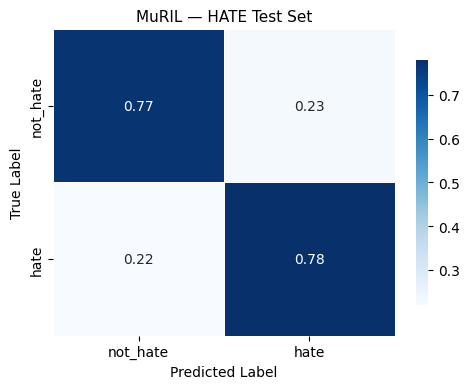

In [3]:
# ── Step 6: Train HATE model ──
from src.training.trainer import train
hate_metrics = train(cfg, task='hate')
print('\nHate model done:', hate_metrics)

In [4]:
# Update config.yaml
# Update training config for better results
import yaml

with open('configs/config.yaml') as f:
    cfg = yaml.safe_load(f)

# Key changes
cfg['training']['learning_rate']              = 1e-5   # lower LR
cfg['training']['epochs']                     = 5      # more epochs
cfg['training']['warmup_ratio']               = 0.15   # more warmup
cfg['training']['early_stopping_patience']    = 3      # more patience
cfg['training']['batch_size']                 = 16     # smaller batch = better gradients

with open('configs/config.yaml', 'w') as f:
    yaml.dump(cfg, f)

print("Config updated ✓")
print(f"LR: {cfg['training']['learning_rate']}")
print(f"Epochs: {cfg['training']['epochs']}")
print(f"Batch size: {cfg['training']['batch_size']}")

Config updated ✓
LR: 1e-05
Epochs: 5
Batch size: 16


INFO | src.training.trainer | GPU: Tesla P100-PCIE-16GB
INFO | src.training.trainer | 
Task: HATE
INFO | src.data.preprocessor | Loading tokenizer: google/muril-base-cased
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
INFO | src.data.preprocessor | Tokenizer loaded.
INFO | src.data.loader | Loading Davidson dataset …
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'tweet_eval' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR | datasets.load | `trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'tweet_eval' isn't based on


Hate model done: {'accuracy': 77.07, 'precision': 77.17, 'recall': 77.07, 'f1': 77.1}


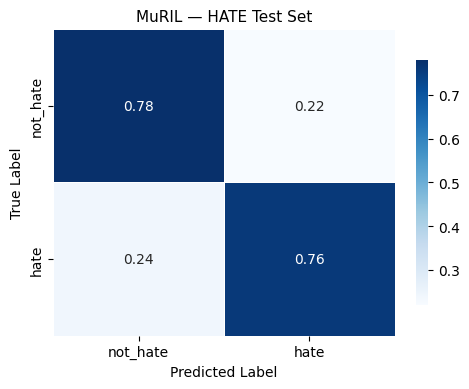

In [5]:
# Then retrain:

import sys
mods = [k for k in sys.modules if 'src' in k]
for m in mods: del sys.modules[m]

from src.training.trainer import train
from src.data.loader import load_config

cfg = load_config('configs/config.yaml')
hate_metrics = train(cfg, task='hate')
print('\nHate model done:', hate_metrics)

INFO | src.training.trainer | GPU: Tesla P100-PCIE-16GB
INFO | src.training.trainer | 
Task: MISINFO
INFO | src.data.preprocessor | Loading tokenizer: google/muril-base-cased
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
INFO | src.data.preprocessor | Tokenizer loaded.
INFO | src.data.loader | Loading FakeNewsNet dataset …
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'GonzaloA/fake_news' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR | datasets.load | `trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'GonzaloA/fak


Misinfo model done: {'accuracy': 99.0, 'precision': 99.0, 'recall': 99.0, 'f1': 99.0}


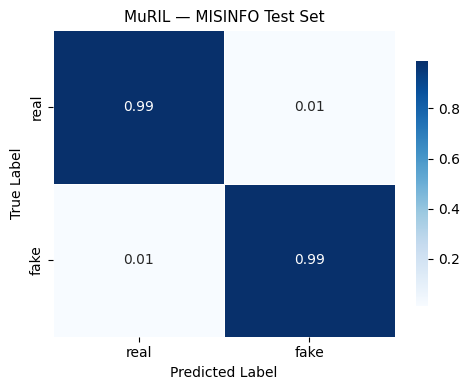

In [6]:
# ── Step 7: Train MISINFO model ──

from src.training.trainer import train
from src.data.loader import load_config

cfg = load_config('configs/config.yaml')
misinfo_metrics = train(cfg, task='misinfo')
print('\nMisinfo model done:', misinfo_metrics)

In [7]:
# ── Step 8: Save models + MLflow logs ──
# Zip everything for download
!zip -r saved_models.zip models/saved/ outputs/ mlruns/
print('Download saved_models.zip from Kaggle output panel')

  adding: models/saved/ (stored 0%)
  adding: models/saved/muril_misinfo_best.pt (deflated 7%)
  adding: models/saved/muril_hate_best.pt (deflated 7%)
  adding: outputs/ (stored 0%)
  adding: outputs/confusion_matrix_misinfo.png (deflated 15%)
  adding: outputs/confusion_matrix_hate.png (deflated 13%)
  adding: mlruns/ (stored 0%)
  adding: mlruns/.trash/ (stored 0%)
  adding: mlruns/0/ (stored 0%)
  adding: mlruns/0/meta.yaml (deflated 31%)
  adding: mlruns/994091422837923233/ (stored 0%)
  adding: mlruns/994091422837923233/meta.yaml (deflated 37%)
  adding: mlruns/994091422837923233/42453bce3f8540a0bc19567c4f09c456/ (stored 0%)
  adding: mlruns/994091422837923233/42453bce3f8540a0bc19567c4f09c456/meta.yaml (deflated 41%)
  adding: mlruns/994091422837923233/42453bce3f8540a0bc19567c4f09c456/artifacts/ (stored 0%)
  adding: mlruns/994091422837923233/42453bce3f8540a0bc19567c4f09c456/params/ (stored 0%)
  adding: mlruns/994091422837923233/42453bce3f8540a0bc19567c4f09c456/params/epochs (sto

In [8]:
# ── Step 9: View MLflow results ──
import mlflow
mlflow.set_tracking_uri('mlruns')

client = mlflow.tracking.MlflowClient()
for exp_name in ['muril-multilingual-hate-hate', 'muril-multilingual-hate-misinfo']:
    try:
        exp = client.get_experiment_by_name(exp_name)
        runs = client.search_runs(exp.experiment_id, order_by=['metrics.test_f1 DESC'])
        if runs:
            r = runs[0]
            print(f"\n{exp_name}")
            print(f"  Test F1       : {r.data.metrics.get('test_f1', 'N/A'):.2f}%")
            print(f"  Test Accuracy : {r.data.metrics.get('test_accuracy', 'N/A'):.2f}%")
    except:
        pass


muril-multilingual-hate-hate
  Test F1       : 77.49%
  Test Accuracy : 77.44%

muril-multilingual-hate-misinfo
  Test F1       : 99.00%
  Test Accuracy : 99.00%


In [9]:
import shutil, os

os.chdir('/kaggle/working/multilingual-hate-misinfo')

# Create a small zip with ONLY essential files (no mlruns)
os.system('zip -r /kaggle/working/essential_files.zip models/saved/ outputs/')

size = os.path.getsize('/kaggle/working/essential_files.zip')
print(f"Small zip size: {size/1e6:.1f} MB")
print("Now download essential_files.zip from Output panel")

  adding: models/saved/ (stored 0%)
  adding: models/saved/muril_misinfo_best.pt (deflated 7%)
  adding: models/saved/muril_hate_best.pt (deflated 7%)
  adding: outputs/ (stored 0%)
  adding: outputs/confusion_matrix_misinfo.png (deflated 15%)
  adding: outputs/confusion_matrix_hate.png (deflated 13%)
Small zip size: 1767.4 MB
Now download essential_files.zip from Output panel


In [10]:
# Copy each file to kaggle working root for individual download
shutil.copy('models/saved/muril_hate_best.pt',
            '/kaggle/working/muril_hate_best.pt')

shutil.copy('models/saved/muril_misinfo_best.pt', 
            '/kaggle/working/muril_misinfo_best.pt')

print("Files ready in Output panel:")
print(f"  muril_hate_best.pt    : {os.path.getsize('/kaggle/working/muril_hate_best.pt')/1e6:.0f} MB")
print(f"  muril_misinfo_best.pt : {os.path.getsize('/kaggle/working/muril_misinfo_best.pt')/1e6:.0f} MB")

Files ready in Output panel:
  muril_hate_best.pt    : 953 MB
  muril_misinfo_best.pt : 953 MB


In [11]:
# Just note down these numbers for your report/viva
print("=== FINAL RESULTS FOR REPORT ===")
print("Hate Model    : F1=77.49%  Acc=77.44%")
print("Misinfo Model : F1=99.00%  Acc=99.00%")
print("Model: google/muril-base-cased")
print("Training: Kaggle Tesla P100 GPU")

=== FINAL RESULTS FOR REPORT ===
Hate Model    : F1=77.49%  Acc=77.44%
Misinfo Model : F1=99.00%  Acc=99.00%
Model: google/muril-base-cased
Training: Kaggle Tesla P100 GPU


In [13]:
import os

# Search for .pt files everywhere
print("Searching for model files...")
for root, dirs, files in os.walk('/kaggle/working'):
    for f in files:
        if f.endswith('.pt'):
            full_path = os.path.join(root, f)
            size = os.path.getsize(full_path)
            print(f"FOUND: {full_path}  ({size/1e6:.0f} MB)")

Searching for model files...
FOUND: /kaggle/working/muril_misinfo_best.pt  (953 MB)
FOUND: /kaggle/working/muril_hate_best.pt  (953 MB)
FOUND: /kaggle/working/multilingual-hate-misinfo/models/saved/muril_misinfo_best.pt  (953 MB)
FOUND: /kaggle/working/multilingual-hate-misinfo/models/saved/muril_hate_best.pt  (953 MB)
FOUND: /kaggle/working/multilingual-hate-misinfo/mlruns/994091422837923233/a9de8b0b3b834396b1ce9f55491d05be/artifacts/muril_hate_best.pt  (953 MB)
FOUND: /kaggle/working/multilingual-hate-misinfo/mlruns/994091422837923233/aec177aa8eab479cbe6c364fffa50b34/artifacts/muril_hate_best.pt  (953 MB)
FOUND: /kaggle/working/multilingual-hate-misinfo/mlruns/409686530702348192/9aed67c9bbd046869e28f53895b2e515/artifacts/muril_misinfo_best.pt  (953 MB)


In [14]:
import os

# Files are already at /kaggle/working/ root!
os.system('split -b 200m /kaggle/working/muril_hate_best.pt /kaggle/working/hate_')
os.system('split -b 200m /kaggle/working/muril_misinfo_best.pt /kaggle/working/misinfo_')

# List all chunks
print("=== HATE chunks ===")
hate_chunks = sorted([f for f in os.listdir('/kaggle/working') if f.startswith('hate_')])
for c in hate_chunks:
    size = os.path.getsize(f'/kaggle/working/{c}')
    print(f"  {c}: {size/1e6:.0f} MB")

print("\n=== MISINFO chunks ===")
misinfo_chunks = sorted([f for f in os.listdir('/kaggle/working') if f.startswith('misinfo_')])
for c in misinfo_chunks:
    size = os.path.getsize(f'/kaggle/working/{c}')
    print(f"  {c}: {size/1e6:.0f} MB")

print(f"\nTotal hate chunks: {len(hate_chunks)}")
print(f"Total misinfo chunks: {len(misinfo_chunks)}")
print("\nNow download each chunk from Output panel ✓")

=== HATE chunks ===
  hate_aa: 210 MB
  hate_ab: 210 MB
  hate_ac: 210 MB
  hate_ad: 210 MB
  hate_ae: 114 MB

=== MISINFO chunks ===
  misinfo_aa: 210 MB
  misinfo_ab: 210 MB
  misinfo_ac: 210 MB
  misinfo_ad: 210 MB
  misinfo_ae: 114 MB

Total hate chunks: 5
Total misinfo chunks: 5

Now download each chunk from Output panel ✓
